## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read the data files

In [2]:
sent = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

## Merge the dataset

In [3]:
sent['date'] = pd.to_datetime(sent['date'], errors='coerce')


trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

print("Timestamp parse errors:", trades['Timestamp IST'].isna().sum())


sentiment_map = {
    'Extreme Fear': 0.0,
    'Fear': 0.25,
    'Neutral': 0.5,
    'Greed': 0.75,
    'Extreme Greed': 1.0
}


sent['sentiment_score'] = sent['classification'].map(sentiment_map)


sent = sent.sort_values('date')
trades = trades.sort_values('Timestamp IST')


merged = pd.merge_asof(
    trades,
    sent[['date', 'classification', 'sentiment_score']],
    left_on='Timestamp IST',
    right_on='date',
    direction='backward'
)


merged.drop(columns=['date'], inplace=True)


merged['sentiment_score'] = merged['sentiment_score'].fillna(method='ffill')


merged['sentiment_score'] = merged['sentiment_score'].fillna(0.5)


print("Merged rows:", merged.shape[0])
print("Missing sentiment rows:", merged['classification'].isnull().sum())


merged.to_csv("/content/mergedfile.csv", index=False)
print("Saved merged file")


Timestamp parse errors: 0
Merged rows: 211224
Missing sentiment rows: 0


/tmp/ipython-input-1988448151.py:41: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['sentiment_score'] = merged['sentiment_score'].fillna(method='ffill')


Saved merged file


## Loading the merge file

In [4]:
df = pd.read_csv('/content/mergedfile.csv')

In [5]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,classification,sentiment_score
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,Greed,0.75
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,Greed,0.75
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,Greed,0.75
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,2023-12-05 03:11:00,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,1.700000e+12,Extreme Greed,1.00
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,2023-12-05 03:11:00,0.0000,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,0.157001,1.070000e+15,1.700000e+12,Extreme Greed,1.00


## cleaning timestamp column

In [6]:
df["Timestamp IST"] = pd.to_datetime(df["Timestamp IST"], errors="coerce")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

## cleaning data

In [7]:
numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Closed PnL", "Fee", "sentiment_score"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


big_int_cols = ["Trade ID", "Order ID"]
for col in big_int_cols:
    df[col] = df[col].astype("Int64")

## preview of clean data

In [8]:

print(df.head())




==== CLEANED DATA PREVIEW ====
                                      Account Coin  Execution Price  \
0  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
1  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1898.6   
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
3  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41866.0   
4  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41867.0   

   Size Tokens  Size USD  Side       Timestamp IST  Start Position  \
0      0.08240    156.39   BUY 2023-05-01 01:06:00          0.0967   
1      0.07220    137.08   BUY 2023-05-01 01:06:00          0.1791   
2      0.09670    183.53   BUY 2023-05-01 01:06:00          0.0000   
3      0.58211  24370.62  SELL 2023-12-05 03:11:00         -0.0150   
4      0.01500    628.00  SELL 2023-12-05 03:11:00          0.0000   

    Direction  Closed PnL                                   Transaction Hash  \
0   Open Long         0.0  0x875d3e1af52

## data info

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  Int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

## missing values

In [10]:
print(df.isna().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
classification      0
sentiment_score     0
dtype: int64


## summary stats

In [11]:
print(df.describe())

       Execution Price   Size Tokens      Size USD  \
count    211224.000000  2.112240e+05  2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   
min           0.000005  8.740000e-07  0.000000e+00   
25%           4.854700  2.940000e+00  1.937900e+02   
50%          18.280000  3.200000e+01  5.970450e+02   
75%         101.580000  1.879025e+02  2.058960e+03   
max      109004.000000  1.582244e+07  3.921431e+06   
std       29447.654868  1.042729e+05  3.657514e+04   

                       Timestamp IST  Start Position     Closed PnL  \
count                         211224    2.112240e+05  211224.000000   
mean   2025-01-31 12:04:22.915009280   -2.994625e+04      48.749001   
min              2023-05-01 01:06:00   -1.433463e+07 -117990.104100   
25%              2024-12-31 21:00:45   -3.762311e+02       0.000000   
50%              2025-02-24 18:55:00    8.472793e+01       0.000000   
75%              2025-04-02 18:22:00    9.337278e+03       5.792797   
max             

## convert numeric col

In [12]:
numeric_cols = [
    "Execution Price", "Size Tokens", "Size USD",
    "Closed PnL", "Fee", "sentiment_score"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## categorical summary

In [13]:
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head())


--- Account ---
Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
Name: count, dtype: int64

--- Coin ---
Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

--- Side ---
Side
SELL    108528
BUY     102696
Name: count, dtype: int64

--- Direction ---
Direction
Open Long      49895
Close Long     48678
Open Short     39741
Close Short    36013
Sell           19902
Name: count, dtype: int64

--- Transaction Hash ---
Transaction Hash
0x0000000000000000000000000000000000000000000000000000000000000000    9032
0x8543ffeb4fdab50bfa0304222f29b702012700b5ee6b85c21ed9215e3bc8ba45     298
0xb3a9e6e4f5293d501bb3041f5c49ec02018b00ecdfb8798414bcd103222f2c30     247
0xa67acabfc24d0cb5d05b041f1704590204f000525423d8cded7ec70825f7b658     

## univariate analysis

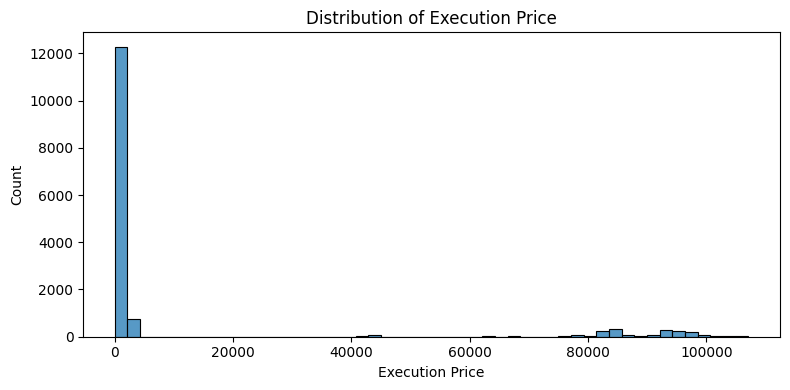

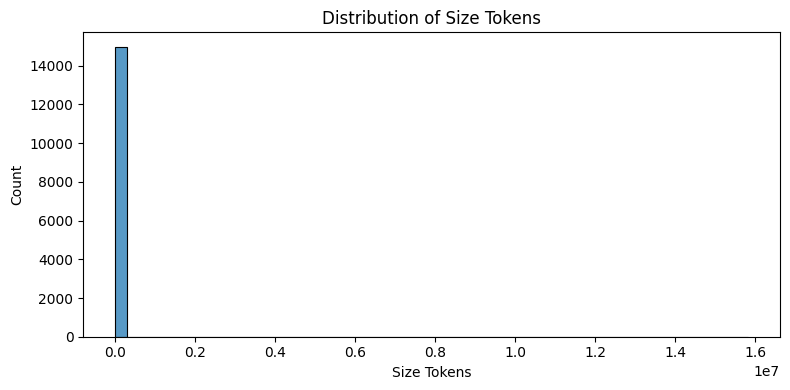

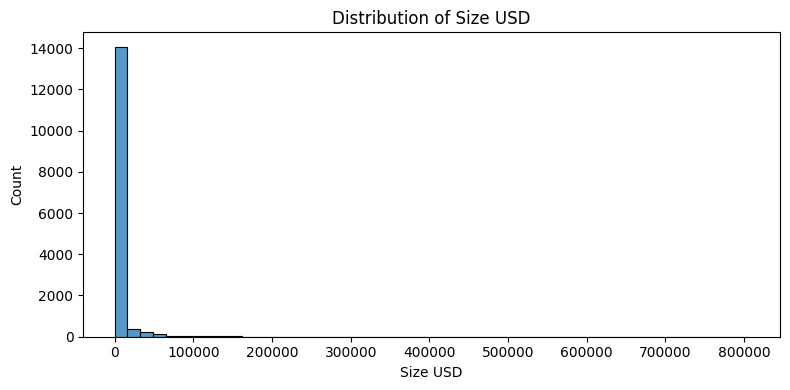

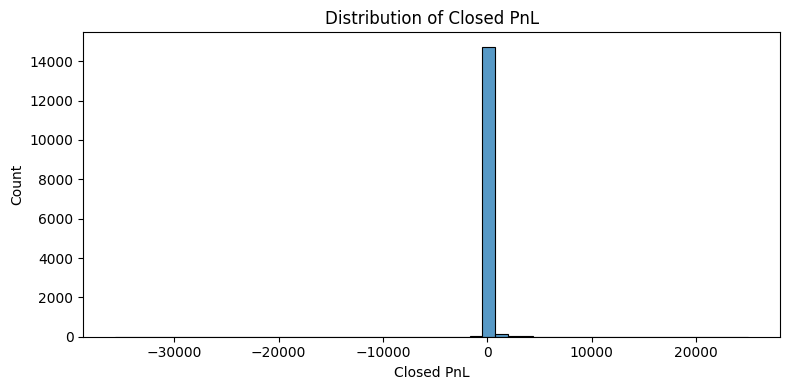

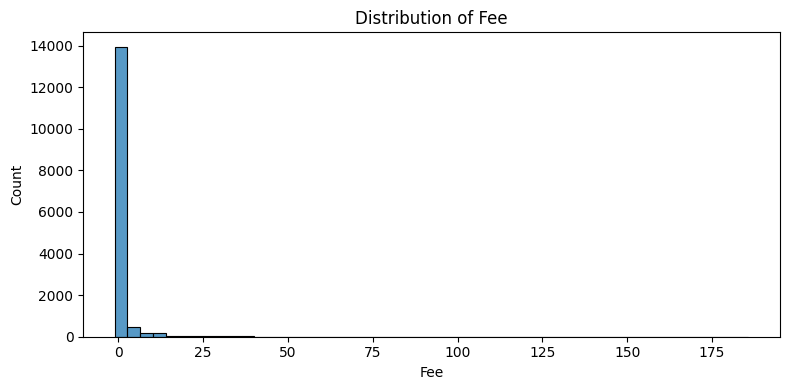

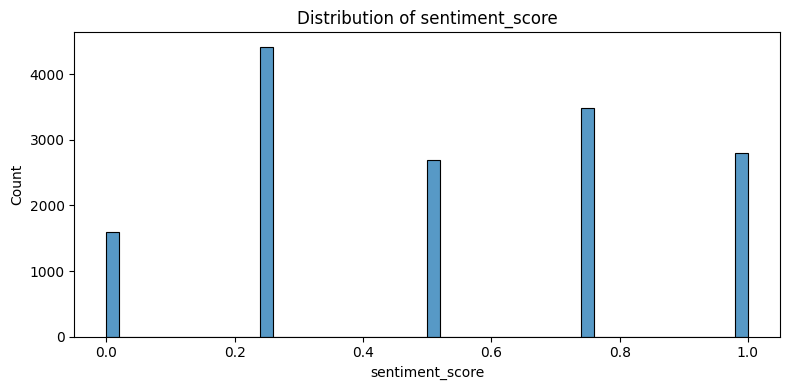

In [15]:
for col in numeric_cols:
    sample = df[col].dropna().sample(15000, random_state=42)

    plt.figure(figsize=(8,4))
    sns.histplot(sample, bins=50)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## categorical features

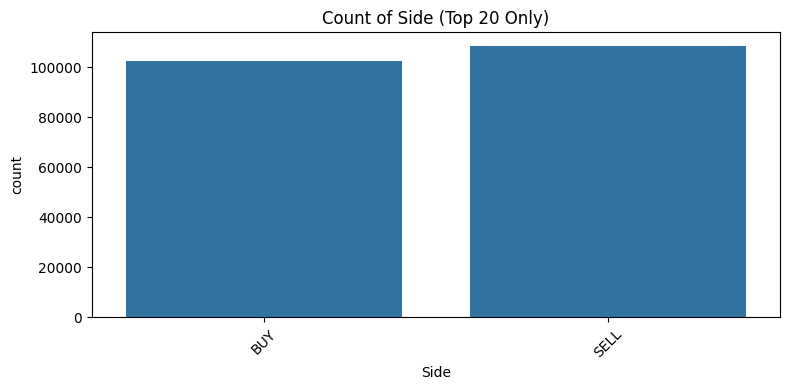

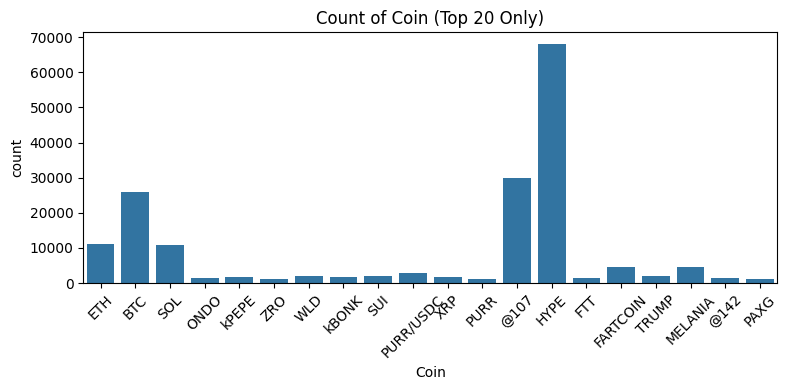

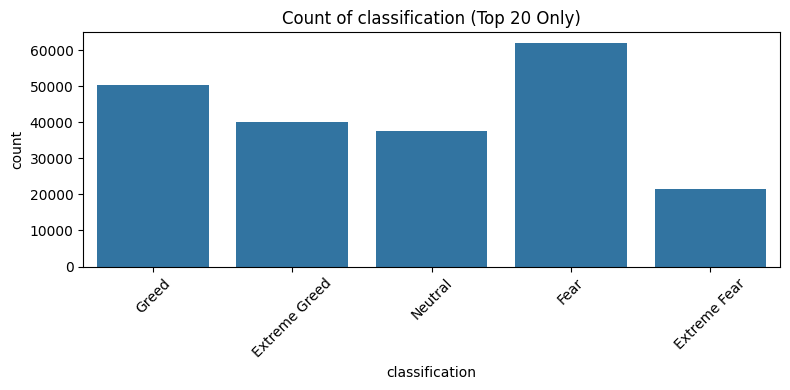

In [16]:
categorical_plots = ["Side", "Coin", "classification"]
for col in categorical_plots:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        top_vals = df[col].value_counts().head(20).index
        sns.countplot(data=df[df[col].isin(top_vals)], x=col)
        plt.title(f"Count of {col} (Top 20 Only)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


## Bivariate analysis

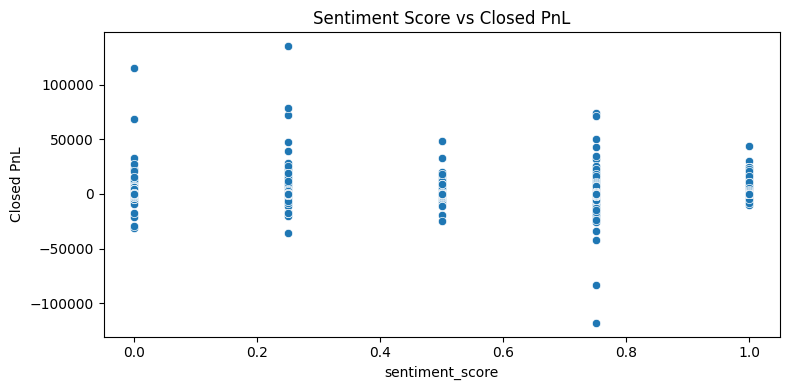

In [17]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=df['sentiment_score'], y=df['Closed PnL'])
plt.title("Sentiment Score vs Closed PnL")
plt.tight_layout()
plt.show()

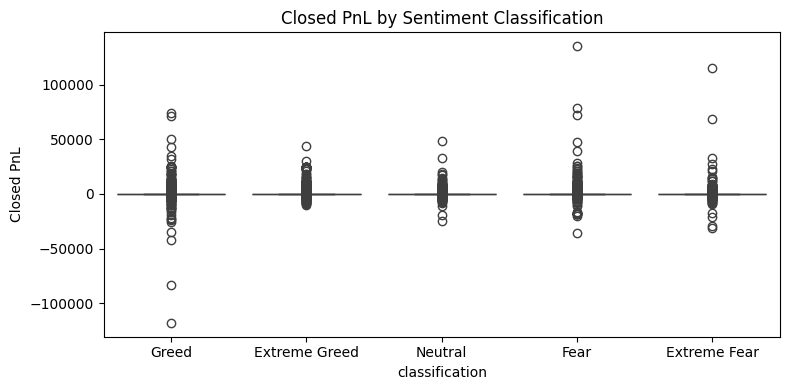

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="classification", y="Closed PnL")
plt.title("Closed PnL by Sentiment Classification")
plt.tight_layout()
plt.show()

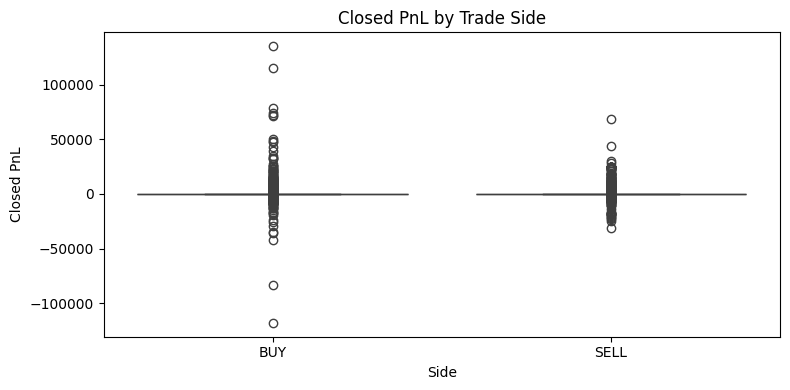

In [19]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Side", y="Closed PnL")
plt.title("Closed PnL by Trade Side")
plt.tight_layout()
plt.show()

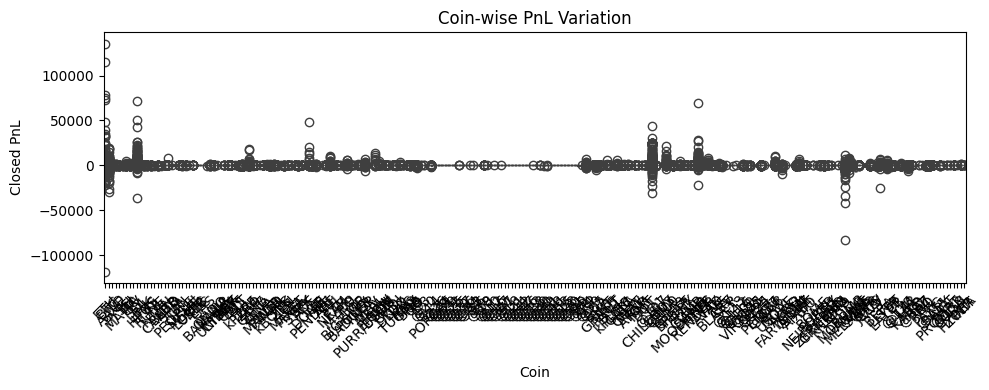

In [20]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Coin", y="Closed PnL")
plt.title("Coin-wise PnL Variation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
df['date'] = df['Timestamp IST'].dt.date

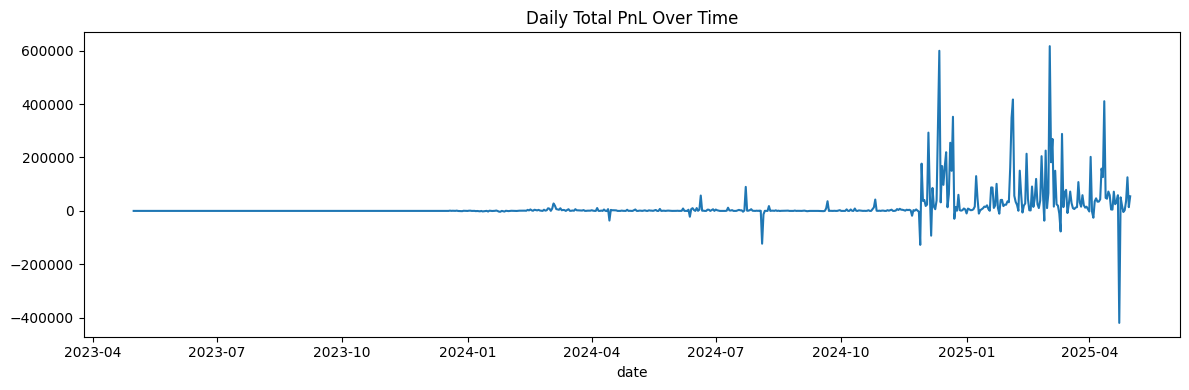

In [22]:
plt.figure(figsize=(12,4))
df.groupby('date')['Closed PnL'].sum().plot()
plt.title("Daily Total PnL Over Time")
plt.tight_layout()
plt.show()

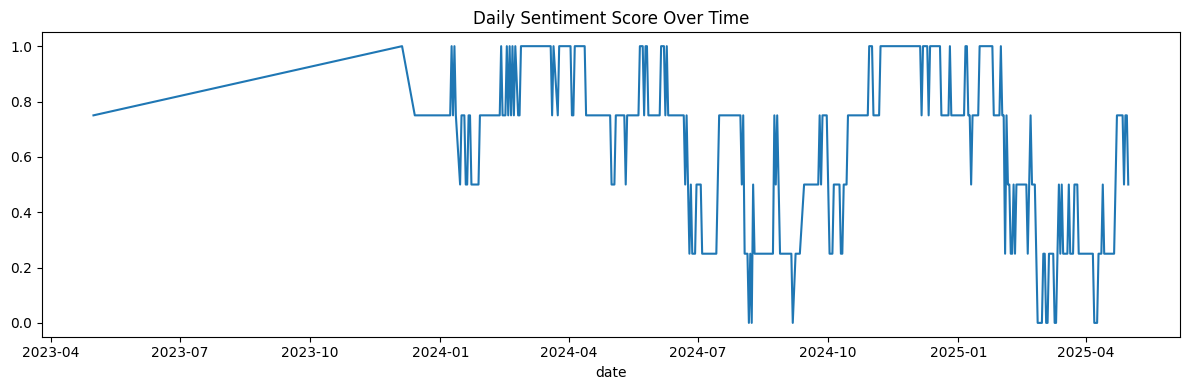

In [23]:
plt.figure(figsize=(12,4))
df.groupby('date')['sentiment_score'].mean().plot()
plt.title("Daily Sentiment Score Over Time")
plt.tight_layout()
plt.show()

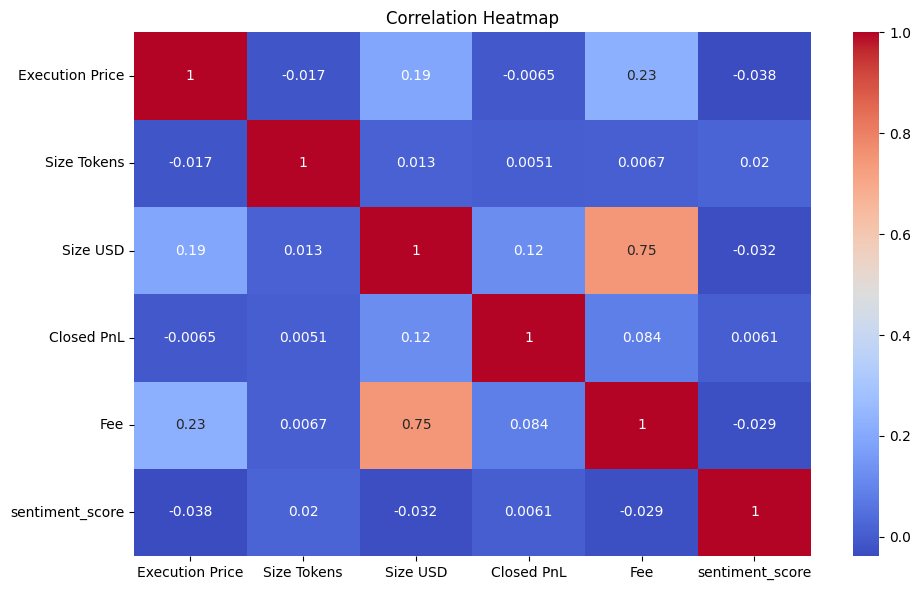

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Outlier detection

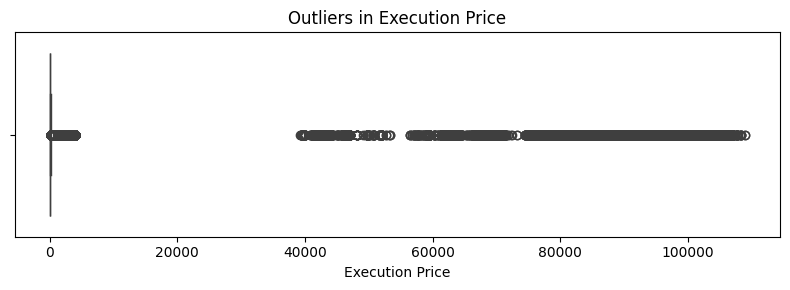

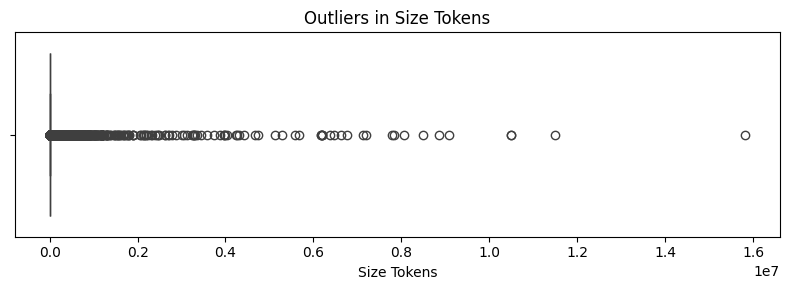

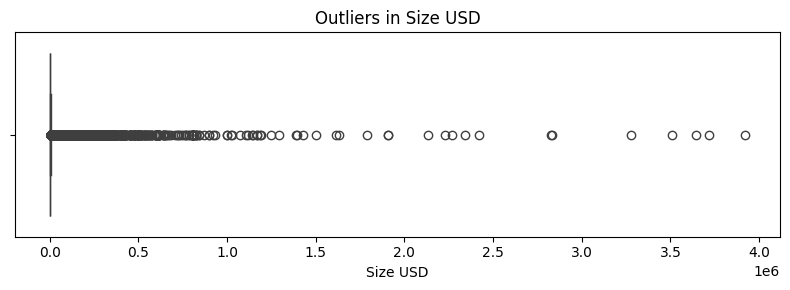

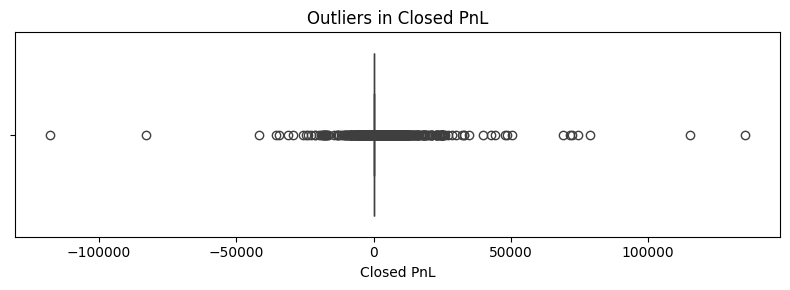

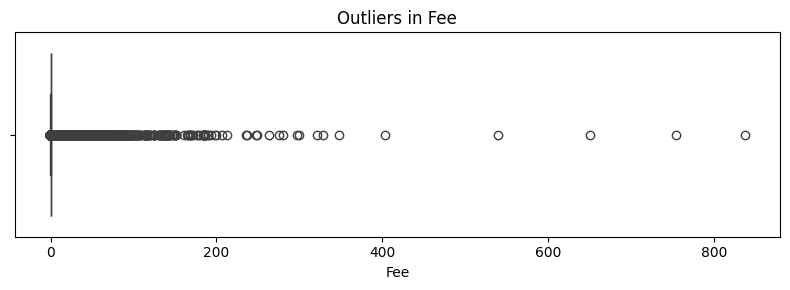

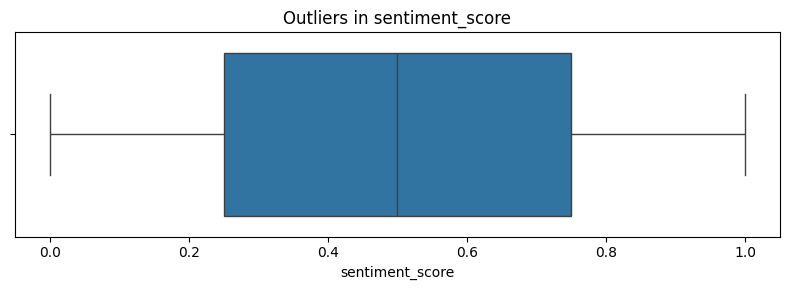

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.tight_layout()
    plt.show()

## Feature engineering

In [33]:
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], errors='coerce')

num_cols = ["Execution Price", "Size Tokens", "Size USD",
            "Closed PnL", "Fee", "sentiment_score"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df['hour'] = df['Timestamp IST'].dt.hour
df['day'] = df['Timestamp IST'].dt.day
df['dayofweek'] = df['Timestamp IST'].dt.dayofweek
df['month'] = df['Timestamp IST'].dt.month
df['year'] = df['Timestamp IST'].dt.year


df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)


def session(hour):
    if 1 <= hour <= 8:
        return "Asia"
    elif 9 <= hour <= 16:
        return "EU"
    else:
        return "US"

df['market_session'] = df['hour'].apply(session)


df["sentiment_bucket"] = pd.cut(
    df["sentiment_score"],
    bins=[-1, 0.33, 0.66, 1],
    labels=["Fear", "Neutral", "Greed"]
)


df["is_extreme"] = df["classification"].isin(["Extreme Greed", "Extreme Fear"]).astype(int)


df = df.sort_values("Timestamp IST")
df["sentiment_lag_1h"] = df["sentiment_score"].shift(1)
df["sentiment_lag_6h"] = df["sentiment_score"].shift(6)
df["sentiment_lag_24h"] = df["sentiment_score"].shift(24)


df["sentiment_roll_mean_6h"] = df["sentiment_score"].rolling(6).mean()
df["sentiment_roll_mean_24h"] = df["sentiment_score"].rolling(24).mean()

# trade feature
df['is_long'] = df['Side'].map({"BUY": 1, "SELL": 0})


df["trade_size_bucket"] = pd.qcut(df["Size USD"], q=4, labels=["small", "medium", "large", "xlarge"])


df["is_win"] = (df["Closed PnL"] > 0).astype(int)


df["pnl_bucket"] = pd.cut(
    df["Closed PnL"],
    bins=[-999999, -50, 0, 50, 999999],
    labels=["big_loss", "loss", "profit", "big_profit"]
)


l1_coins = ["BTC", "ETH", "SOL", "ADA", "BNB"]
df["coin_category"] = df["Coin"].apply(lambda x: "L1" if x in l1_coins else "Other")


df["trader_avg_pnl"] = df.groupby("Account")["Closed PnL"].transform(lambda x: x.rolling(20, min_periods=1).mean())
df["trader_total_trades"] = df.groupby("Account").cumcount()


df["coin_volatility"] = df.groupby("Coin")["Execution Price"].transform(
    lambda x: x.pct_change().rolling(24).std()
)


cat_cols = ["Side", "classification", "trade_size_bucket",
            "market_session", "coin_category", "pnl_bucket"]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


df = df.dropna(subset=["Closed PnL", "sentiment_score"])


df.to_csv("engineered_trades_sentiment.csv", index=False)

print("Feature engineering done. Saved as engineered_trades_sentiment.csv")


Feature engineering done. Saved as engineered_trades_sentiment.csv
